# Interactive Controls & Dynamics Demo
## Conveyor Belt Speed Control

Control a factory conveyor belt driven by a DC motor. Tune PID gains, apply product-load
disturbances, and see how transfer functions, state-space models, and feedback loops
connect in a real manufacturing system.

**The same ideas apply to:** spindle speed regulation, pump speed control, line-rate
regulation under varying demand, and any speed-servo in a production machine.

---
## 1 - Setup and Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import control as ct
import sympy as sp
from sympy.physics.control.lti import TransferFunction as SymTF
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, Latex

import demo_helpers as dh

print("All imports OK")

All imports OK


---
## 2 - Plant Definition

The conveyor belt + DC motor is modeled as a second-order system:

$$G(s) = \frac{K \, \omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$$

- **K** = DC gain (steady-state speed per volt)
- **wn** = natural frequency (how fast the belt responds)
- **zeta** = damping ratio (overshoot vs sluggishness)

We build this plant three ways: python-control transfer function, state-space, and SymPy symbolic.

In [4]:
# ---- Editable plant parameters ----
K_plant = 1.0    # DC gain [m/s per V]
wn      = 2.0    # Natural frequency [rad/s]
zeta    = 0.4    # Damping ratio (< 1 = underdamped)
# -----------------------------------

In [5]:
# --- Transfer function (python-control) ---
num = [K_plant * wn**2]
den = [1, 2*zeta*wn, wn**2]
G = ct.tf(num, den)
print("Plant transfer function G(s):")
print(G)
print(f"\nPoles: {G.poles()}")
print(f"DC gain: {ct.dcgain(G):.3f}")

Plant transfer function G(s):
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         4
  ---------------
  s^2 + 1.6 s + 4

Poles: [-0.8+1.83303028j -0.8-1.83303028j]
DC gain: 1.000


In [6]:
# --- State-space form (python-control) ---
# States: x1 = belt speed, x2 = rate of change of speed
# x' = A*x + B*u,  y = C*x
A_mat = np.array([[0, 1],
                   [-wn**2, -2*zeta*wn]])
B_mat = np.array([[0],
                   [K_plant * wn**2]])
C_mat = np.array([[1, 0]])
D_mat = np.array([[0]])

G_ss = ct.ss(A_mat, B_mat, C_mat, D_mat)
print("State-space model:")
print(G_ss)
print(f"\nEigenvalues of A: {np.linalg.eigvals(A_mat)}")

State-space model:
<StateSpace>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[ 0.   1. ]
     [-4.  -1.6]]

B = [[0.]
     [4.]]

C = [[1. 0.]]

D = [[0.]]

Eigenvalues of A: [-0.8+1.83303028j -0.8-1.83303028j]


In [7]:
# --- Symbolic transfer function (SymPy) ---
# Useful for seeing the math and deriving properties symbolically
s = sp.Symbol('s')
K_sym, wn_sym, zeta_sym = sp.symbols('K omega_n zeta', positive=True)

G_sym = SymTF(K_sym * wn_sym**2,
              s**2 + 2*zeta_sym*wn_sym*s + wn_sym**2, s)

print("SymPy transfer function (symbolic):")
display(Latex(f"$G(s) = {sp.latex(G_sym.to_expr())}$"))

# Substitute numerical values
G_num_expr = G_sym.to_expr().subs({K_sym: K_plant, wn_sym: wn, zeta_sym: zeta})
print(f"\nWith K={K_plant}, wn={wn}, zeta={zeta}:")
display(Latex(f"$G(s) = {sp.latex(sp.simplify(G_num_expr))}$"))

SymPy transfer function (symbolic):


<IPython.core.display.Latex object>


With K=1.0, wn=2.0, zeta=0.4:


<IPython.core.display.Latex object>

---
## 3 - Open-Loop Dynamics

Before closing the loop, let's see how the plant responds on its own.

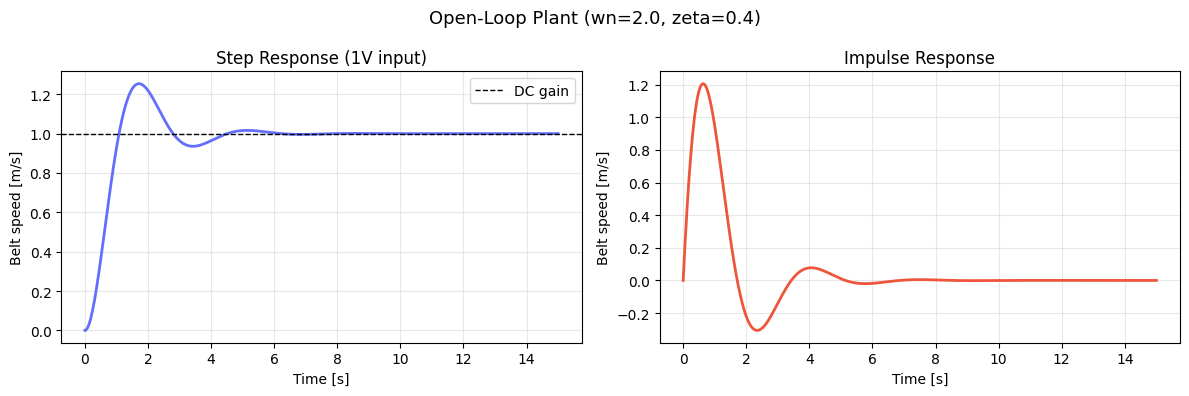

Poles:             [-0.8+1.83303028j -0.8-1.83303028j]
Natural freq wn:   2.0 rad/s  (0.32 Hz)
Damping ratio:     0.4
DC gain:           1.000 m/s per V


In [8]:
# Step response using python-control
t_ol = np.linspace(0, 15, 500)
t_step, y_step = ct.step_response(G, T=t_ol)

# Impulse response using python-control
t_imp, y_imp = ct.impulse_response(G, T=t_ol)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_step, y_step, color='#636EFA', linewidth=2)
axes[0].axhline(ct.dcgain(G), color='black', linestyle='--', linewidth=1, label='DC gain')
axes[0].set_title('Step Response (1V input)')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Belt speed [m/s]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_imp, y_imp, color='#EF553B', linewidth=2)
axes[1].set_title('Impulse Response')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Belt speed [m/s]')
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Open-Loop Plant (wn={wn}, zeta={zeta})', fontsize=13)
fig.tight_layout()
plt.show()

# Key quantities
poles = G.poles()
print(f"Poles:             {poles}")
print(f"Natural freq wn:   {wn} rad/s  ({wn/(2*np.pi):.2f} Hz)")
print(f"Damping ratio:     {zeta}")
print(f"DC gain:           {ct.dcgain(G):.3f} m/s per V")

In [9]:
# Same step response via scipy.signal for comparison
sys_scipy = signal.TransferFunction(num, den)
t_sc, y_sc = signal.step(sys_scipy, T=t_ol)

print("scipy.signal step response matches python-control:")
print(f"  Max difference: {np.max(np.abs(np.interp(t_sc, t_step, y_step) - y_sc)):.2e}")

scipy.signal step response matches python-control:
  Max difference: 2.00e-15


---
## 4 - Closed-Loop Control

Now we close the loop. The controller C(s) drives the plant G(s) in a unity-feedback configuration:

```
ref -->(+)-->[C(s)]-->[G(s)]---+--> y (belt speed)
        ^                      |
        |_______(-)____________|
```

We compare P, PI, and PID controllers.

In [10]:
# ---- Editable controller gains ----
Kp = 5.0
Ki = 2.0
Kd = 0.5
# -----------------------------------

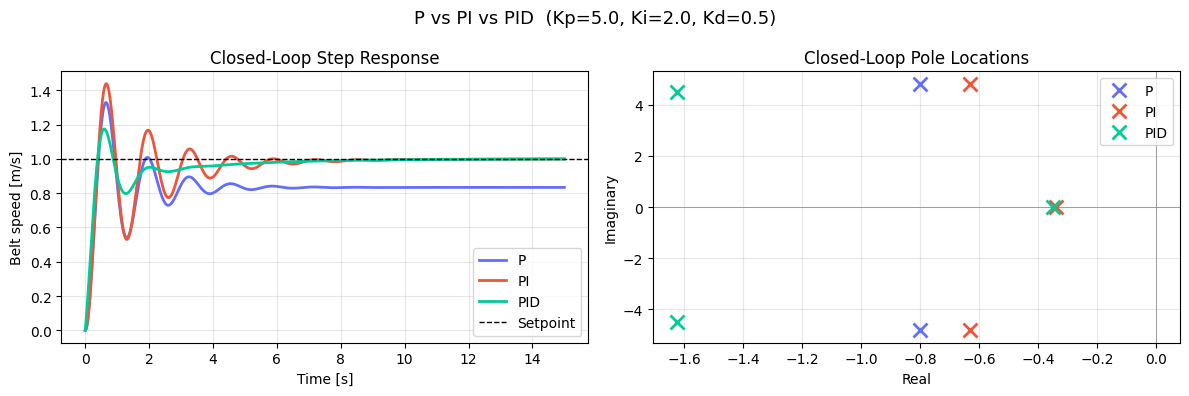

Steady-state tracking (unit step):
  P   DC gain = 0.8333   (error = 0.1667)
  PI  DC gain = 1.0000   (error = 0.0000)
  PID DC gain = 1.0000   (error = 0.0000)


In [11]:
# Build controllers as transfer functions
C_p   = ct.tf([Kp], [1])                                  # P:   Kp
C_pi  = ct.tf([Kp, Ki], [1, 0])                           # PI:  Kp + Ki/s
C_pid = ct.tf([Kd, Kp, Ki], [1, 0])                       # PID: Kd*s + Kp + Ki/s

# Closed-loop transfer functions:  T(s) = C*G / (1 + C*G)
T_p   = ct.feedback(C_p * G)
T_pi  = ct.feedback(C_pi * G)
T_pid = ct.feedback(C_pid * G)

t_cl = np.linspace(0, 15, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, T_sys, color in [("P", T_p, "#636EFA"),
                             ("PI", T_pi, "#EF553B"),
                             ("PID", T_pid, "#00CC96")]:
    t_r, y_r = ct.step_response(T_sys, T=t_cl)
    axes[0].plot(t_r, y_r, label=label, color=color, linewidth=2)

axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1, label='Setpoint')
axes[0].set_title('Closed-Loop Step Response')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Belt speed [m/s]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pole locations
for label, T_sys, color in [("P", T_p, "#636EFA"),
                             ("PI", T_pi, "#EF553B"),
                             ("PID", T_pid, "#00CC96")]:
    p = T_sys.poles()
    axes[1].plot(np.real(p), np.imag(p), 'x', color=color, markersize=10, markeredgewidth=2, label=label)

axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_title('Closed-Loop Pole Locations')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Imaginary')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'P vs PI vs PID  (Kp={Kp}, Ki={Ki}, Kd={Kd})', fontsize=13)
fig.tight_layout()
plt.show()

print(f"Steady-state tracking (unit step):")
print(f"  P   DC gain = {ct.dcgain(T_p):.4f}   (error = {1 - ct.dcgain(T_p):.4f})")
print(f"  PI  DC gain = {ct.dcgain(T_pi):.4f}   (error = {1 - ct.dcgain(T_pi):.4f})")
print(f"  PID DC gain = {ct.dcgain(T_pid):.4f}   (error = {1 - ct.dcgain(T_pid):.4f})")

---
## 5 - Disturbance and Realism

Real conveyors encounter product loads dropping onto the belt.  The controller must reject
this disturbance and maintain speed.  The motor voltage is also limited (actuator saturation).

We switch to the explicit simulation in `demo_helpers` which models saturation and anti-windup.

In [12]:
plant = dh.default_plant_params()
plant.update(wn=wn, zeta=zeta, K_plant=K_plant)

ctrl = dh.default_controller_params()
ctrl.update(Kp=Kp, Ki=Ki, Kd=Kd)

sim = dh.default_sim_params()

t_arr = np.arange(0, sim["t_end"], sim["dt"])
ref, dist = dh.build_scenario(t_arr, scenario="load_step", target_speed=1.0)
result = dh.simulate(plant, ctrl, sim, ref, dist)

fig = dh.build_figure(result, title="Disturbance Rejection: Load Hits Belt at t=10s")
fig.show()

# Compare with open-loop
ol_result = dh.simulate_open_loop(plant, sim, u_const=1.0, dist=dist)
print(f"Open-loop speed at t=20s:   {ol_result['y'][-1]:.3f} m/s  (no feedback)")
print(f"Closed-loop speed at t=20s: {result['y'][-1]:.3f} m/s  (PID feedback)")

Open-loop speed at t=20s:   0.000 m/s  (no feedback)
Closed-loop speed at t=20s: 1.000 m/s  (PID feedback)


In [13]:
# Show what happens with aggressive gains and tight actuator limits
ctrl_aggressive = dict(Kp=20.0, Ki=10.0, Kd=2.0, u_min=0.0, u_max=5.0, anti_windup=True)
ref_full, dist_full = dh.build_scenario(t_arr, scenario="full", target_speed=1.0)

res_aggressive = dh.simulate(plant, ctrl_aggressive, sim, ref_full, dist_full)
fig2 = dh.build_figure(res_aggressive,
    title="Aggressive Gains + Tight Saturation (u_max=5V) + Load + Speed Changes")
fig2.show()

---
## 6 - Interactive Exploration

Use the sliders to tune the PID controller and change plant parameters.

**Things to try:**
- Crank up `Kp` -- speed tracks faster but overshoots.
- Add `Ki` -- eliminates steady-state error, especially under load.
- Add `Kd` -- dampens the ringing.
- Lower `wn` -- makes the belt sluggish (heavy or loose belt).
- Switch to **full** scenario and try to keep the belt on target.

In [14]:
try:
    fig_widget = go.FigureWidget(
        make_subplots(
            rows=3, cols=1, shared_xaxes=True,
            subplot_titles=("Belt Speed vs Target", "Control Effort (Voltage)", "Disturbance Load"),
            vertical_spacing=0.08,
        )
    )

    # Pre-add empty traces
    fig_widget.add_trace(go.Scatter(x=[], y=[], mode="lines", name="Target speed",
                                    line=dict(color="black", dash="dash", width=1.5)), row=1, col=1)
    fig_widget.add_trace(go.Scatter(x=[], y=[], mode="lines", name="Belt speed",
                                    line=dict(color="#636EFA", width=2)), row=1, col=1)
    fig_widget.add_trace(go.Scatter(x=[], y=[], mode="lines", name="Applied voltage",
                                    line=dict(color="#EF553B", width=1.5)), row=2, col=1)
    fig_widget.add_trace(go.Scatter(x=[], y=[], mode="lines", name="Load disturbance",
                                    line=dict(color="#00CC96", width=1.5),
                                    fill="tozeroy", fillcolor="rgba(0,204,150,0.15)"), row=3, col=1)

    fig_widget.update_yaxes(title_text="Speed [m/s]", row=1, col=1)
    fig_widget.update_yaxes(title_text="Voltage [V]", row=2, col=1)
    fig_widget.update_yaxes(title_text="Load [N]", row=3, col=1)
    fig_widget.update_xaxes(title_text="Time [s]", row=3, col=1)
    fig_widget.update_layout(
        template="plotly_white", height=700,
        showlegend=True,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
        margin=dict(t=60, b=40),
    )

    ss = dict(style={"description_width": "110px"}, layout=widgets.Layout(width="430px"))

    w_Kp   = widgets.FloatSlider(value=5.0,  min=0.0, max=30.0, step=0.5,  description="Kp", **ss)
    w_Ki   = widgets.FloatSlider(value=2.0,  min=0.0, max=20.0, step=0.5,  description="Ki", **ss)
    w_Kd   = widgets.FloatSlider(value=0.5,  min=0.0, max=5.0,  step=0.1,  description="Kd", **ss)
    w_wn   = widgets.FloatSlider(value=2.0,  min=0.5, max=8.0,  step=0.25, description="Plant wn", **ss)
    w_zeta = widgets.FloatSlider(value=0.4,  min=0.1, max=2.0,  step=0.05, description="Plant zeta", **ss)
    w_umax = widgets.FloatSlider(value=10.0, min=2.0, max=20.0, step=1.0,  description="u_max [V]", **ss)
    w_target = widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1,  description="Target [m/s]", **ss)
    w_scenario = widgets.Dropdown(
        options=["step", "load_step", "speed_change", "full"],
        value="load_step", description="Scenario",
        style={"description_width": "110px"}, layout=widgets.Layout(width="430px"),
    )

    def update_interactive(change=None):
        p = dh.default_plant_params()
        p.update(wn=w_wn.value, zeta=w_zeta.value)
        c = dh.default_controller_params()
        c.update(Kp=w_Kp.value, Ki=w_Ki.value, Kd=w_Kd.value, u_max=w_umax.value)
        s = dh.default_sim_params()

        t = np.arange(0, s["t_end"], s["dt"])
        ref, dist = dh.build_scenario(t, scenario=w_scenario.value, target_speed=w_target.value)
        res = dh.simulate(p, c, s, ref, dist)

        with fig_widget.batch_update():
            fig_widget.data[0].x = res["t"]
            fig_widget.data[0].y = res["ref"]
            fig_widget.data[1].x = res["t"]
            fig_widget.data[1].y = res["y"]
            fig_widget.data[2].x = res["t"]
            fig_widget.data[2].y = res["u"]
            fig_widget.data[3].x = res["t"]
            fig_widget.data[3].y = res["dist"]

    for w in [w_Kp, w_Ki, w_Kd, w_wn, w_zeta, w_umax, w_target, w_scenario]:
        w.observe(update_interactive, names="value")

    controls = widgets.VBox([
        widgets.HTML("<b>PID Gains</b>"),
        w_Kp, w_Ki, w_Kd,
        widgets.HTML("<b>Plant / Scenario</b>"),
        w_wn, w_zeta, w_umax, w_target, w_scenario,
    ])

    update_interactive()
    display(widgets.HBox([controls, fig_widget]))

except (ImportError, Exception) as exc:
    print(f"(Interactive widgets unavailable: {exc})")
    print("Showing static plot with default parameters instead.")
    p = dh.default_plant_params()
    c = dh.default_controller_params()
    s = dh.default_sim_params()
    t = np.arange(0, s["t_end"], s["dt"])
    ref, dist = dh.build_scenario(t, scenario="load_step", target_speed=1.0)
    res = dh.simulate(p, c, s, ref, dist)
    fig = dh.build_figure(res, title="Interactive Tuning (static fallback)")
    fig.show()

---
## 7 - Student Challenges

### Challenge A: Fast and Stable
Using the **step** scenario with target = 1.5 m/s, find gains that:
- Reach target within **3 seconds**
- Overshoot less than **10%**
- No oscillation after 6 seconds

### Challenge B: Reject the Load
Using the **load_step** scenario, find gains that:
- Recover to within 5% of target within **4 seconds** after the load hits
- Keep the voltage under 8V at all times

### Challenge C: Open-Loop vs Closed-Loop
Run the cell below with your gains, then set `Kp = Ki = Kd = 0` and re-run.
What happens to the belt speed when the load hits? Why does feedback matter?

In [15]:
# ---- YOUR GAINS HERE ----
ch_Kp = 5.0
ch_Ki = 2.0
ch_Kd = 0.5
# -------------------------

p = dh.default_plant_params()
c = dh.default_controller_params()
c.update(Kp=ch_Kp, Ki=ch_Ki, Kd=ch_Kd)
s = dh.default_sim_params()

t_ch = np.arange(0, s["t_end"], s["dt"])
ref_ch, dist_ch = dh.build_scenario(t_ch, scenario="load_step", target_speed=1.5)
res_ch = dh.simulate(p, c, s, ref_ch, dist_ch)

# Evaluate
y = res_ch["y"]
target_val = 1.5
within_band = np.abs(y - target_val) < 0.05 * target_val
reach_idx = np.where(within_band)[0]
reach_time = res_ch["t"][reach_idx[0]] if len(reach_idx) > 0 else None
overshoot_pct = (np.max(y[:2000]) - target_val) / target_val * 100
max_voltage = np.max(res_ch["u"])

# Post-disturbance recovery (load at t=10)
post_load_idx = res_ch["t"] >= 10.0
post_load_y = y[post_load_idx]
post_load_t = res_ch["t"][post_load_idx]
recovery_band = np.abs(post_load_y - ref_ch[post_load_idx]) < 0.05 * target_val
recover_idx = np.where(recovery_band)[0]
recovery_time = (post_load_t[recover_idx[0]] - 10.0) if len(recover_idx) > 0 else None

print("=" * 55)
print("  CHALLENGE RESULTS")
print("=" * 55)
if reach_time is not None:
    print(f"  Reach time:        {reach_time:.2f}s  {'PASS' if reach_time < 3 else 'FAIL'} (target < 3s)")
else:
    print("  Reach time:        FAIL (never reached)")
print(f"  Overshoot:         {overshoot_pct:.1f}%  {'PASS' if overshoot_pct < 10 else 'FAIL'} (target < 10%)")
print(f"  Max voltage:       {max_voltage:.1f}V  {'PASS' if max_voltage < 8 else 'FAIL'} (target < 8V)")
if recovery_time is not None:
    print(f"  Load recovery:     {recovery_time:.2f}s  {'PASS' if recovery_time < 4 else 'FAIL'} (target < 4s)")
else:
    print("  Load recovery:     FAIL (never recovered)")
print("=" * 55)

fig = dh.build_figure(res_ch, title="Challenge Results")
fig.show()

  CHALLENGE RESULTS
  Reach time:        0.46s  PASS (target < 3s)
  Overshoot:         23.1%  FAIL (target < 10%)
  Max voltage:       10.0V  FAIL (target < 8V)
  Load recovery:     0.00s  PASS (target < 4s)


---
## Bonus - P vs PI vs PID with Explicit Simulation

Same plant, same disturbance, three controllers side by side.

In [16]:
p = dh.default_plant_params()
s = dh.default_sim_params()
t_b = np.arange(0, s["t_end"], s["dt"])
ref_b, dist_b = dh.build_scenario(t_b, scenario="load_step", target_speed=1.0)

cases = [
    ("P only  (Kp=5)",             dict(Kp=5.0, Ki=0.0, Kd=0.0, u_min=0, u_max=10, anti_windup=True), "#636EFA"),
    ("PI      (Kp=5, Ki=2)",       dict(Kp=5.0, Ki=2.0, Kd=0.0, u_min=0, u_max=10, anti_windup=True), "#EF553B"),
    ("PID     (Kp=5, Ki=2, Kd=0.5)", dict(Kp=5.0, Ki=2.0, Kd=0.5, u_min=0, u_max=10, anti_windup=True), "#00CC96"),
]

traces = []
for label, gains, color in cases:
    res = dh.simulate(p, gains, s, ref_b, dist_b)
    traces.append(dict(label=label, y=res["y"], u=res["u"], color=color))

fig = dh.build_comparison_figure(t_b, traces,
    title="P vs PI vs PID under Load Disturbance")

# Add reference and disturbance marker
fig.add_trace(go.Scatter(x=t_b, y=ref_b, mode="lines",
    name="Target", line=dict(color="black", dash="dash", width=1.5)), row=1, col=1)
fig.show()

---

**Key takeaways:**
- The plant transfer function and state-space model describe the same physical system two ways.
- Open-loop shows what the belt does on its own. Closed-loop adds intelligence.
- P control is fast but leaves steady-state error. PI eliminates it. PID adds damping.
- Actuator saturation and disturbances are real constraints in every manufacturing system.
- Tuning PID is always a tradeoff between speed, overshoot, and control effort.

These same concepts apply directly to any speed or rate control loop on a production floor.